<a href="https://colab.research.google.com/github/lrrod/mackprojetoIV/blob/main/cd_projeto_aplicado_IV_doc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/02**


# **Documentação do Projeto**

---

# **Título do Projeto**

**Previsão do consumo de energia elétrica da Região Sudeste do Brasil com variáveis climáticas e de atividade industrial: um produto analítico para o planejamento energético de cidades sustentáveis (ODS 11)**

---

In [8]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Eduardo Pinheiro Canas, 10184419' #@param {type:"string"}
Aluno2 = 'Hugo de Moraes Holzer, 10142961' #@param {type:"string"}
Aluno3 = 'Luiz Rodrigo Alves Vergino, 10176038' #@param {type:"string"}



# **Resumo**

# **INTRODUÇÃO**

A energia elétrica é o insumo que sustenta o funcionamento da sociedade contemporânea: dela dependem os domicílios, o comércio, os serviços públicos, os sistemas de transporte e o parque industrial (a própria produção industrial). No Brasil, a Região Sudeste concentra a maior parcela da demanda nacional com consumo de cerca de 21,5 mil GWh mensais, aproximadamente metade do consumo do país (BANCO CENTRAL DO BRASIL, 2026) e além disso abriga as maiores regiões metropolitanas do território nacional.

A previsão de qualidade desta demanda nos ajuda e evitar dois cenários, um de previsão abaixo do necessário, expondo a população a riscos de desabastecimento e racionamento, e outro acima do necessário gerando investimentos ociosos e pressão tarifária. O tema ganhou atualidade com a intensificação das ondas de calor, que elevam a demanda por climatização e têm produzido recordes sucessivos de carga no sistema elétrico brasileiro (EMPRESA DE PESQUISA ENERGÉTICA, 2026), e conecta-se diretamente ao Objetivo de Desenvolvimento Sustentável número 11: Cidades e Comunidades Sustentáveis, na medida em que o suprimento confiável e eficiente de energia é condição para cidades resilientes (ORGANIZAÇÃO DAS NAÇÕES UNIDAS, 2015).

Duas forças externas exercem influência relevante sobre a série: a temperatura, que impulsiona o consumo residencial e comercial por meio de refrigeração e climatização, e o nível de atividade industrial, que responde por parcela expressiva da demanda total. Se desenvolvermos um modelo puramente univariado estaremos ignorando essa relação (HYNDMAN; ATHANASOPOULOS, 2021). Em análise preliminar da base construída para este projeto, a correlação entre as variações interanuais do consumo e da produção industrial paulista foi de 0,71, e a correlação entre as anomalias sazonais de consumo e de temperatura foi de 0,54. Portanto temos a hipótese fundamentada que estas variáveis explicativas carregam informação útil para a previsão.

Portanto o objetivo geral do projeto é desenvolver um produto analítico baseado em séries temporais para a previsão do consumo de energia elétrica da Região Sudeste do Brasil com granularidade mensal, incorporando variáveis exógenas climáticas e de atividade industrial. Definem-se os seguintes objetivos específicos:

**(i)** construir, por meio de coleta automatizada em APIs públicas oficiais (portanto trabalharemos com dados reais e atualizados), uma base de dados multivariada integrada, com granularidade mensal e período superior a duas décadas;

**(ii)** realizar a análise exploratória e a decomposição da série de consumo, caracterizando tendência, sazonalidade, ciclos e resíduos;

**(iii)** levantar e comparar técnicas de previsão, como os modelos da família ARIMA (BOX et al., 2015), e baseadas em aprendizado de máquina, como redes LSTM (HOCHREITER; SCHMIDHUBER, 1997) e o Prophet (TAYLOR; LETHAM, 2018);

**(iv)** implementar ao menos um modelo univariado de referência (baseline SARIMA) e um modelo multivariado com variáveis exógenas (SARIMAX), avaliando-os por métricas de erro (MAPE, RMSE, MAE) sobre um conjunto de teste reservado ao final da série;

**(v)** traduzir os resultados em insights acionáveis para o planejamento energético.

A escolha da solução proposta configura um produto com um pipeline automatizado que coleta os dados diretamente das APIs oficiais a cada nova divulgação mensal e será despriorizado a utilização de arquivos estáticos com o objetivo de manter o produto atualizado. Será desenvolvido etapas de tratamento, treinamento, validação e geração de previsões com intervalos de confiança. A coleta e a integração das três fontes já foram implementadas e executadas com sucesso (seção de EDA e Pré-processamento), o que elimina o principal risco técnico do projeto. Como evolução, a arquitetura prevê a ingestão dos dados de carga horária disponibilizados em tempo quase real pelo Operador Nacional do Sistema Elétrico (2026), aproximando o produto de um cenário de processamento de dados em streaming.

O projeto justifica-se por suas contribuições em duas frentes. Do ponto de vista científico e metodológico, oferece um estudo de caso aberto e reprodutível: dados e código públicos, em consonância com o caráter extensionista da disciplina. Do ponto de vista social, um modelo preditivo de demanda elétrica com bom desempenho fornece subsídios ao poder público, às distribuidoras e aos agentes do setor para antecipar picos de consumo, dimensionar a oferta e planejar a expansão da infraestrutura urbana, beneficiando diretamente os mais de 89 milhões de habitantes da região mais populosa do país.

**Descrição da base de dados.**

A base do projeto é *multivariada, com **granularidade mensal*, organizada em formato longitudinal (uma linha por mês, indexada pela data) e construída pela integração e junção pela chave ano-mês, de três fontes públicas oficiais, todas acessadas por APIs gratuitas e de coleta reprodutível em código:

| # | Variável | Fonte | Forma de acesso | Período na fonte | Registros |
|---|----------|-------|-----------------|------------------|-----------|
| 1 | Consumo de energia elétrica — Região Sudeste (GWh) — **variável-alvo** | Eletrobras, via SGS/Banco Central do Brasil, série 1431 | API REST (JSON) | fev/1979 – jun/2026 | 569 |
| 2 | Produção física industrial — SP (índice, base 2022 = 100) — exógena | PIM-PF/IBGE, tabela 8888 da API SIDRA | API REST (JSON) | jan/2002 – jun/2026 | 294 |
| 3 | Temperatura média mensal do ar a 2 m — São Paulo (°C) — exógena | NASA POWER (ponto 23,55° S, 46,63° O) | API REST (JSON) | jan/2002 – dez/2025 | 288 |

Após a integração, a base final cobre o período de **janeiro de 2002 a dezembro de 2025, com 288 registros mensais completos** com quatro atributos: tempo (mês), consumo (alvo), produção industrial e temperatura (exógenas). A série-alvo dispõe ainda de recortes setoriais (residencial, comercial e industrial) e regionais no SGS (BANCO CENTRAL DO BRASIL, 2026), que poderão ser explorados nas etapas seguintes; a produção industrial é medida pelo IBGE (2026) e a temperatura pelo projeto NASA POWER (NASA, 2026), adotado como fonte climática principal pela estabilidade de acesso via API, tendo as séries de estação do INMET/BDMEP como fonte oficial brasileira alternativa. A originalidade da base se justifica pela composição própria de três fontes primárias, com coleta automatizada que se atualiza a cada divulgação mensal dos órgãos oficiais.

# **Referencial Teórico**


O objeto central deste projeto é a série temporal, ou seja, uma sequência de observações ordenadas no tempo com periodicidade definida, que neste caso é mensal.

A análise clássica decompõe uma série em quatro componentes: tendência (direção de longo prazo), sazonalidade (padrões que se repetem em períodos fixos), ciclos (oscilações de período irregular) e resíduos (variação não explicada) (HYNDMAN; ATHANASOPOULOS, 2021). Outro conceito fundamental é a estacionariedade, ou seja, a estabilidade da média e da variância ao longo do tempo, que é verificável por testes como o de Dickey-Fuller Aumentado (ADF); Já séries não estacionárias, como o consumo de energia em crescimento, exigem diferenciação antes da modelagem estatística (BOX et al., 2015).

Entre as técnicas estatísticas, a família ARIMA combina componentes autorregressivos (AR), de diferenciação (I) e de médias móveis (MA); a variante SARIMA adiciona termos sazonais, e a SARIMAX incorpora variáveis exógenas ao modelo. Suas vantagens são a interpretabilidade dos parâmetros, a produção natural de intervalos de confiança e o bom desempenho com amostras moderadas; sua principal limitação é a estrutura linear (BOX et al., 2015). A relevância das exógenas neste domínio é consolidada na literatura: Hong e Fan (2016), em revisão do estado da arte em previsão de carga elétrica, apontam a temperatura como a variável explicativa mais importante da demanda; Elamin e Fukushige (2018) aplicaram SARIMAX com variáveis meteorológicas e de calendário à previsão de demanda horária, obtendo ganhos de acurácia ao modelar também os efeitos de interação entre elas.

Como alternativas de aprendizado de máquina, as redes LSTM (HOCHREITER; SCHMIDHUBER, 1997) capturam dependências não lineares e de longo prazo, mas exigem maior volume de dados, ajuste de hiperparâmetros e oferecem menor interpretabilidade; o Prophet (TAYLOR; LETHAM, 2018) modela a série como soma de tendência, sazonalidades e feriados, sendo robusto a outliers e dados faltantes, porém menos flexível para incorporar regressores externos contínuos com estrutura complexa.

Dois trabalhos correlatos abordaram exatamente o problema deste projeto — a previsão do consumo de energia elétrica da Região Sudeste. Santos e Chaucoski (2020) compararam SARIMA e LSTM sobre dados mensais da EPE (2004–2020, 197 observações) e concluíram que ambas as técnicas produzem estimativas confiáveis para o curto prazo. Gonçalves (2025), com dados mensais de 2002 a 2023 da mesma região, verificou que o ARIMA captura melhor os padrões sazonais de curto prazo, enquanto a LSTM se destaca em tendências não lineares, sugerindo a combinação de abordagens. Ambos os estudos, contudo, compartilham a mesma limitação: a modelagem exclusivamente univariada, que ignora os determinantes climáticos e econômicos da demanda. Este projeto se posiciona precisamente nessa lacuna, ao confrontar um baseline univariado (SARIMA) com um modelo multivariado (SARIMAX) alimentado por temperatura e produção industrial, sob protocolo único de validação — conjunto de teste reservado ao final da série e métricas MAPE, RMSE e MAE.

# **Diagrama de Solução**

O diagrama abaixo apresenta o pipeline da solução, organizado em sete estágios. (1) **Coleta automatizada**: as três fontes são consultadas diretamente em suas APIs públicas (SGS/BCB, SIDRA/IBGE e NASA POWER) a cada execução, garantindo que o produto sempre opere com os dados mais recentes — sem arquivos estáticos. (2) **Tratamento e integração**: tipagem, indexação temporal e junção pela chave ano-mês, com verificação de integridade (a base atual tem 288 meses sem valores faltantes). (3) **EDA e decomposição**: caracterização de tendência, sazonalidade e resíduos de cada série (já iniciada na seção seguinte) e identificação de outliers — como o racionamento de 2001 e a pandemia de 2020 — que serão tratados antes da modelagem. (4) **Partição temporal**: os últimos 12 meses são reservados como conjunto de teste, simulando o uso real do produto (prever um ano à frente); nenhuma informação do teste vaza para o treinamento. (5) **Modelagem**: o baseline univariado SARIMA e o modelo principal SARIMAX com exógenas disputam sob as mesmas condições; LSTM e Prophet permanecem como candidatos para experimentos complementares. (6) **Validação**: comparação por MAPE, RMSE e MAE sobre o teste. (7) **Produto analítico**: previsões de 12 meses com intervalos de confiança e insights para o planejamento energético, com retreino mensal automático a cada nova divulgação das fontes e, como evolução futura, ingestão da carga horária dos dados abertos do ONS em tempo quase real.

A viabilidade do pipeline está demonstrada em duas frentes: os estágios 1–2 já executam com sucesso neste documento, e os estágios 4–6 seguem protocolo padrão da literatura (HYNDMAN; ATHANASOPOULOS, 2021), sem dependências externas além de bibliotecas Python de código aberto.

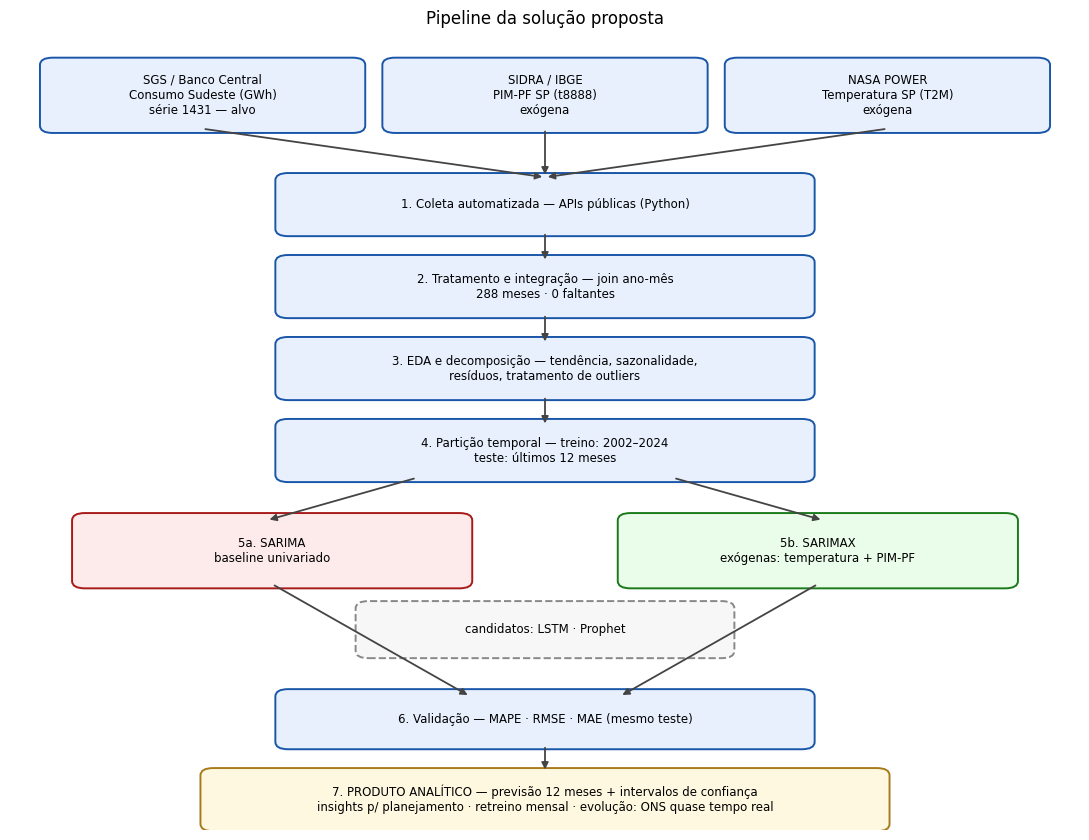

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


fig, ax = plt.subplots(figsize=(11, 8.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')

def caixa(x, y, w, h, texto, cor='#e8f0fe', borda='#1a56a8', ls='-'):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                 facecolor=cor, edgecolor=borda, linewidth=1.4, linestyle=ls))
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=8.5)

def seta(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#444444', lw=1.3))

# (1) Fontes de dados
caixa(0.4, 11.6, 2.8, 1.0, 'SGS / Banco Central\nConsumo Sudeste (GWh)\nsérie 1431 — alvo')
caixa(3.6, 11.6, 2.8, 1.0, 'SIDRA / IBGE\nPIM-PF SP (t8888)\nexógena')
caixa(6.8, 11.6, 2.8, 1.0, 'NASA POWER\nTemperatura SP (T2M)\nexógena')
for xc in (1.8, 5.0, 8.2): seta(xc, 11.55, 5.0, 10.75)

# (2)–(4) Estágios sequenciais
caixa(2.6, 9.9, 4.8, 0.8, '1. Coleta automatizada — APIs públicas (Python)')
seta(5.0, 9.85, 5.0, 9.35)
caixa(2.6, 8.55, 4.8, 0.8, '2. Tratamento e integração — join ano-mês\n288 meses · 0 faltantes')
seta(5.0, 8.5, 5.0, 8.0)
caixa(2.6, 7.2, 4.8, 0.8, '3. EDA e decomposição — tendência, sazonalidade,\nresíduos, tratamento de outliers')
seta(5.0, 7.15, 5.0, 6.65)
caixa(2.6, 5.85, 4.8, 0.8, '4. Partição temporal — treino: 2002–2024\nteste: últimos 12 meses')
seta(3.8, 5.8, 2.4, 5.1); seta(6.2, 5.8, 7.6, 5.1)

# (5) Modelagem — comparação
caixa(0.7, 4.1, 3.5, 1.0, '5a. SARIMA\nbaseline univariado', cor='#fdeaea', borda='#a81a1a')
caixa(5.8, 4.1, 3.5, 1.0, '5b. SARIMAX\nexógenas: temperatura + PIM-PF', cor='#eafdea', borda='#1a7a1a')
caixa(3.35, 2.95, 3.3, 0.7, 'candidatos: LSTM · Prophet', cor='#f7f7f7', borda='#888888', ls='--')
seta(2.45, 4.05, 4.3, 2.2); seta(7.55, 4.05, 5.7, 2.2)

# (6)–(7) Validação e produto
caixa(2.6, 1.45, 4.8, 0.75, '6. Validação — MAPE · RMSE · MAE (mesmo teste)')
seta(5.0, 1.4, 5.0, 0.95)
caixa(1.9, 0.1, 6.2, 0.8, '7. PRODUTO ANALÍTICO — previsão 12 meses + intervalos de confiança\ninsights p/ planejamento · retreino mensal · evolução: ONS quase tempo real',
      cor='#fff8e1', borda='#a87b1a')

ax.set_title('Pipeline da solução proposta', fontsize=12, pad=12)
plt.tight_layout(); plt.show()

# **Cronograma**

O cronograma abaixo detalha todas as atividades planejadas até a conclusão do projeto, distribuídas pelas quatro entregas da disciplina (marcos em negrito). As atividades internas foram dimensionadas com sobreposição controlada e folga de revisão antes de cada entrega.

| # | Atividade | Início | Fim | Entrega | Status |
|---|-----------|--------|-----|---------|--------|
| 1 | Definição do tema, equipe e repositório | 17/08 | 24/08 | E1 | Concluída |
| 2 | Validação das fontes e construção da base integrada | 24/08 | 29/08 | E1 | Concluída |
| 3 | Redação da introdução e descrição da base | 29/08 | 30/08 | E1 | Concluída |
| 4 | **Entrega 1 — Definição do projeto e equipe** | — | **31/08** | E1 | Concluída |
| 5 | Pesquisa de trabalhos correlatos | 08/09 | 14/09 | E2 | Concluída |
| 6 | Decomposição preliminar das três séries (EDA inicial) | 12/09 | 18/09 | E2 | Concluída |
| 7 | Redação do referencial teórico | 15/09 | 19/09 | E2 | Concluída |
| 8 | Diagrama e discussão do pipeline | 17/09 | 19/09 | E2 | Concluída |
| 9 | Elaboração do cronograma detalhado | 19/09 | 19/09 | E2 | Concluída |
| 10 | Revisão do documento pelo grupo | 20/09 | 26/09 | E2 | Concluída |
| 11 | **Entrega 2 — Referencial teórico e cronograma** | — | **28/09** | E2 | Concluída |
| 12 | Testes de estacionariedade (ADF) e transformações | 29/09 | 05/10 | E3 | Planejada |
| 13 | Tratamento de outliers (pandemia 2020) e engenharia de atributos | 03/10 | 09/10 | E3 | Planejada |
| 14 | Implementação e ajuste do baseline SARIMA | 06/10 | 13/10 | E3 | Planejada |
| 15 | Implementação do SARIMAX e seleção de exógenas | 10/10 | 18/10 | E3 | Planejada |
| 16 | Validação no conjunto de teste (MAPE, RMSE, MAE) | 17/10 | 22/10 | E3 | Planejada |
| 17 | Documentação dos resultados parciais | 21/10 | 25/10 | E3 | Planejada |
| 18 | **Entrega 3 — Implementação parcial** | — | **26/10** | E3 | Planejada |
| 19 | Experimentos complementares (Prophet e/ou LSTM) | 27/10 | 08/11 | E4 | Planejada |
| 20 | Comparação final dos modelos e análise crítica | 06/11 | 15/11 | E4 | Planejada |
| 21 | Discussão, conclusão e melhorias futuras | 13/11 | 20/11 | E4 | Planejada |
| 22 | Elaboração dos slides da apresentação | 16/11 | 21/11 | E4 | Planejada |
| 23 | Gravação e edição do vídeo (até 10 min, YouTube) | 22/11 | 27/11 | E4 | Planejada |
| 24 | Revisão final da documentação e do repositório | 26/11 | 29/11 | E4 | Planejada |
| 25 | **Entrega 4 — Implementação e entrega final** | — | **30/11** | E4 | Planejada |

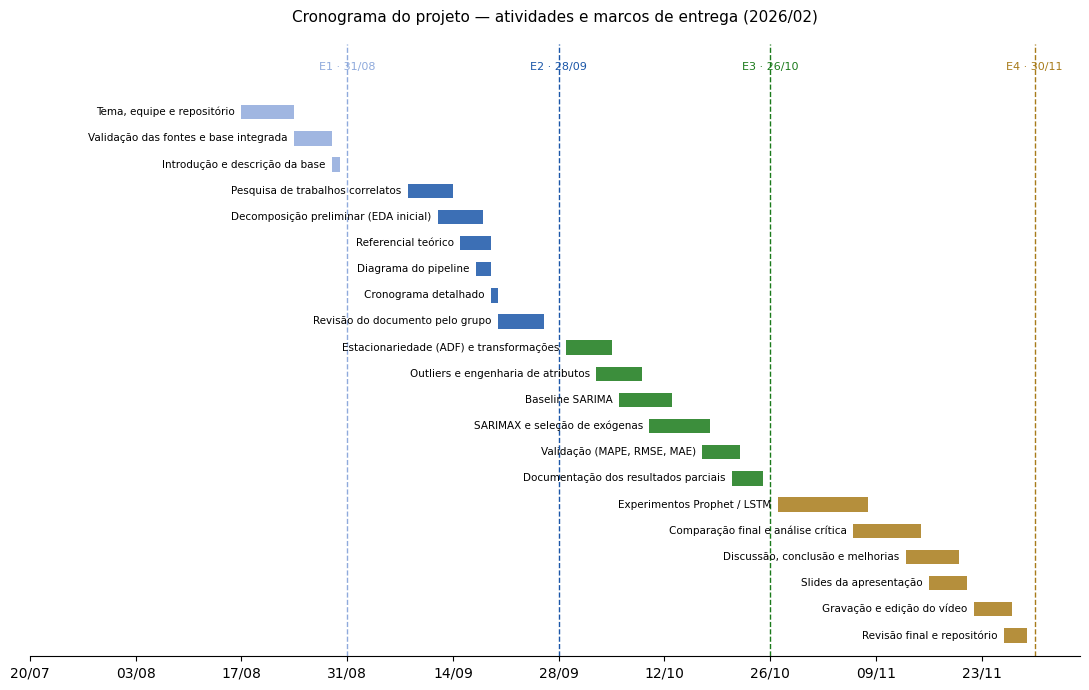

In [10]:
from datetime import date
import matplotlib.dates as mdates

atividades = [  # (nome, início, fim, entrega)
    ('Tema, equipe e repositório',            date(2026,8,17),  date(2026,8,24),  'E1'),
    ('Validação das fontes e base integrada', date(2026,8,24),  date(2026,8,29),  'E1'),
    ('Introdução e descrição da base',        date(2026,8,29),  date(2026,8,30),  'E1'),
    ('Pesquisa de trabalhos correlatos',      date(2026,9,8),   date(2026,9,14),  'E2'),
    ('Decomposição preliminar (EDA inicial)', date(2026,9,12),  date(2026,9,18),  'E2'),
    ('Referencial teórico',                   date(2026,9,15),  date(2026,9,19),  'E2'),
    ('Diagrama do pipeline',                  date(2026,9,17),  date(2026,9,19),  'E2'),
    ('Cronograma detalhado',                  date(2026,9,19),  date(2026,9,19),  'E2'),
    ('Revisão do documento pelo grupo',       date(2026,9,20),  date(2026,9,26),  'E2'),
    ('Estacionariedade (ADF) e transformações', date(2026,9,29), date(2026,10,5), 'E3'),
    ('Outliers e engenharia de atributos',    date(2026,10,3),  date(2026,10,9),  'E3'),
    ('Baseline SARIMA',                       date(2026,10,6),  date(2026,10,13), 'E3'),
    ('SARIMAX e seleção de exógenas',         date(2026,10,10), date(2026,10,18), 'E3'),
    ('Validação (MAPE, RMSE, MAE)',           date(2026,10,17), date(2026,10,22), 'E3'),
    ('Documentação dos resultados parciais',  date(2026,10,21), date(2026,10,25), 'E3'),
    ('Experimentos Prophet / LSTM',           date(2026,10,27), date(2026,11,8),  'E4'),
    ('Comparação final e análise crítica',    date(2026,11,6),  date(2026,11,15), 'E4'),
    ('Discussão, conclusão e melhorias',      date(2026,11,13), date(2026,11,20), 'E4'),
    ('Slides da apresentação',                date(2026,11,16), date(2026,11,21), 'E4'),
    ('Gravação e edição do vídeo',            date(2026,11,22), date(2026,11,27), 'E4'),
    ('Revisão final e repositório',           date(2026,11,26), date(2026,11,29), 'E4'),
]
entregas = {'E1': date(2026,8,31), 'E2': date(2026,9,28), 'E3': date(2026,10,26), 'E4': date(2026,11,30)}
cores = {'E1': '#8faadc', 'E2': '#1a56a8', 'E3': '#1a7a1a', 'E4': '#a87b1a'}

fig, ax = plt.subplots(figsize=(11, 7))
for i, (nome, ini, fim, et) in enumerate(reversed(atividades)):
    dur = max((fim - ini).days, 1)
    ax.barh(i, dur, left=ini, height=0.55, color=cores[et], alpha=0.85)
    ax.text(ini, i, nome + '  ', ha='right', va='center', fontsize=7.5)
for et, d in entregas.items():
    ax.axvline(d, color=cores[et], linestyle='--', linewidth=1)
    ax.text(d, len(atividades) + 0.6, f'{et} · {d:%d/%m}', ha='center', fontsize=8, color=cores[et])
ax.set_yticks([]); ax.set_ylim(-0.8, len(atividades) + 1.6)
ax.set_xlim(date(2026,7,20), date(2026,12,6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_title('Cronograma do projeto — atividades e marcos de entrega (2026/02)', fontsize=11, pad=16)
plt.tight_layout(); plt.show()

# **EDA e Pré-processamento dos dados**

O código a seguir demonstra a viabilidade da solução: reproduz integralmente a obtenção das três fontes, a integração pela chave ano-mês e a verificação de integridade da base.

In [11]:
import urllib.request, json, gzip
import pandas as pd
import json
from statsmodels.tsa.seasonal import seasonal_decompose

def obter_json(url):

    # REQUISIÇÃO GET COM SUPORTE A GZIP
    # TODAS AS FONTES SÃO APIS PÚBLICAS

    req = urllib.request.Request(url, headers={'Accept-Encoding': 'gzip', 'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=90) as r:
        raw = r.read()
    if raw[:2] == b'\x1f\x8b':
        raw = gzip.decompress(raw)
    return json.loads(raw.decode())

**FONTE 1: CONSUMO DE ENERGIA ELÉTRICA - REGIÃO SUDESTE (GWh)**

*BANCO CENTRAL DO BRASIL, 2026*

In [12]:
### Fonte 1: Consumo de energia elétrica — Região Sudeste (GWh) — SGS/BCB, série 1431
consumo = pd.DataFrame(obter_json('https://api.bcb.gov.br/dados/serie/bcdata.sgs.1431/dados?formato=json'))
consumo.head()

,data,valor
0,01/02/1979,5551
1,01/03/1979,5725
2,01/04/1979,5797
3,01/05/1979,6002
4,01/06/1979,5988


In [13]:
consumo['data'] = pd.to_datetime(consumo['data'], format='%d/%m/%Y')
consumo['consumo_gwh'] = pd.to_numeric(consumo['valor'])
consumo = consumo.set_index('data')[['consumo_gwh']].asfreq('MS')
print(f'Consumo Sudeste : {len(consumo)} registros | {consumo.index.min():%m/%Y} a {consumo.index.max():%m/%Y}')

Consumo Sudeste : 570 registros | 02/1979 a 07/2026


Análise de Decomposição da Série Temporal de Consumo de Energia:


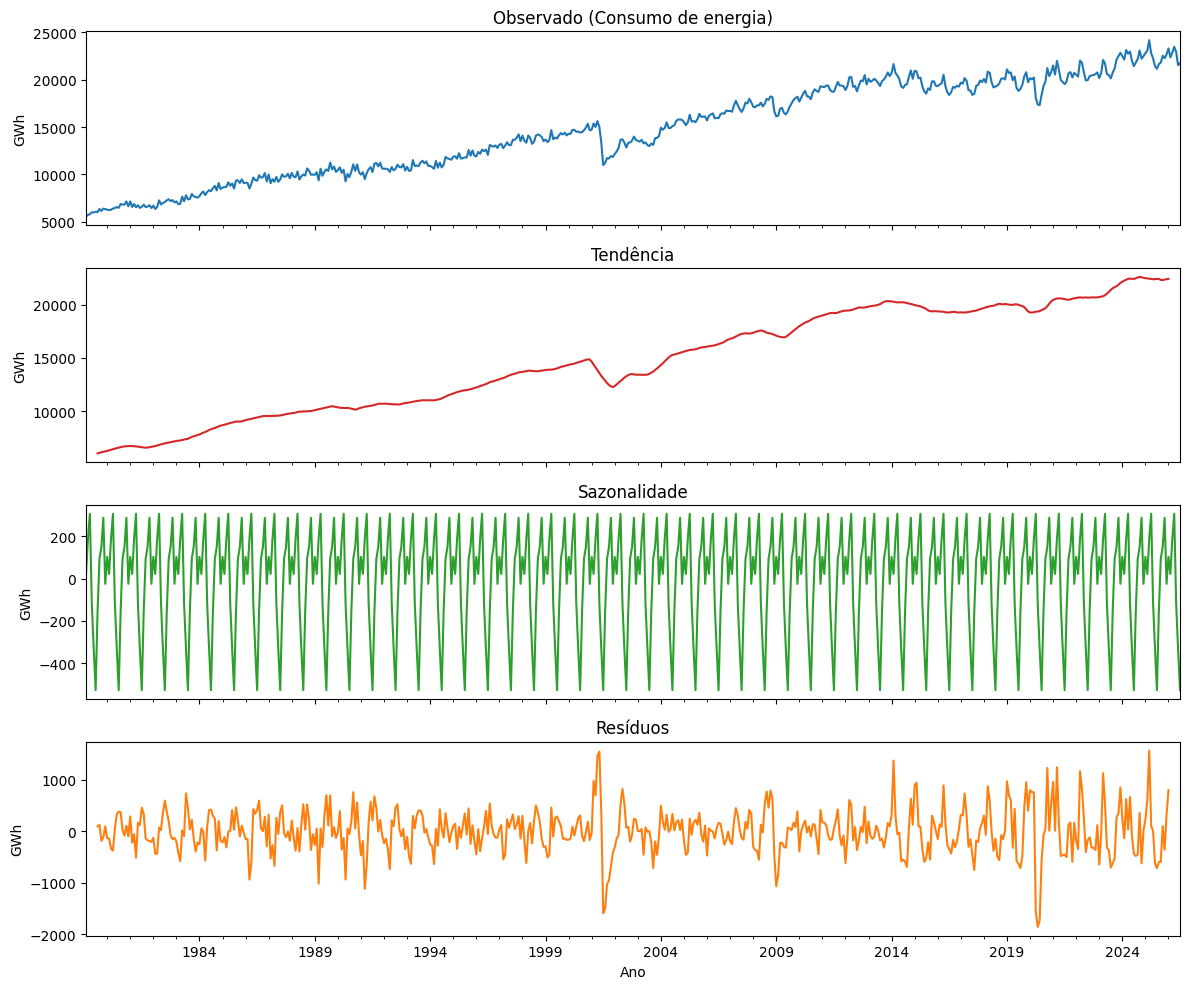

In [14]:
# ANALISE DE TENDENCIAS, SAZONALIDADE E RESIDUO

consumoexplorado = seasonal_decompose(consumo['consumo_gwh'], model='additive', period=12)

# PLOT DOS COMPONENTES
print('Análise de Decomposição da Série Temporal de Consumo de Energia:')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

consumoexplorado.observed.plot(ax=ax1, title='Observado (Consumo de energia)', color='#1f77b4')
ax1.set_ylabel('GWh')

consumoexplorado.trend.plot(ax=ax2, title='Tendência', color='#d62728')
ax2.set_ylabel('GWh')

consumoexplorado.seasonal.plot(ax=ax3, title='Sazonalidade', color='#2ca02c')
ax3.set_ylabel('GWh')

consumoexplorado.resid.plot(ax=ax4, title='Resíduos', color='#ff7f0e')
ax4.set_ylabel('GWh')
ax4.set_xlabel('Ano')

plt.tight_layout()
plt.show()






**FONTE 2: PRODUÇÃO FÍSICA INDUSTRIAL - SP**

*IBGE*

In [15]:
### Fonte 2: Produção física industrial — SP — PIM-PF/IBGE (SIDRA t8888, v12606) ──
pim_raw = obter_json('https://apisidra.ibge.gov.br/values/t/8888/n3/35/v/12606/p/all/c544/129314?formato=json') [1:]
pim = pd.DataFrame(pim_raw)
pim.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,3,Unidade da Federação,30,Número-índice,81.43223,35,São Paulo,12606,PIMPF - Número-índice (2022=100),200201,janeiro 2002,129314,1 Indústria geral
1,3,Unidade da Federação,30,Número-índice,80.73734,35,São Paulo,12606,PIMPF - Número-índice (2022=100),200202,fevereiro 2002,129314,1 Indústria geral
2,3,Unidade da Federação,30,Número-índice,88.74597,35,São Paulo,12606,PIMPF - Número-índice (2022=100),200203,março 2002,129314,1 Indústria geral
3,3,Unidade da Federação,30,Número-índice,91.07592,35,São Paulo,12606,PIMPF - Número-índice (2022=100),200204,abril 2002,129314,1 Indústria geral
4,3,Unidade da Federação,30,Número-índice,94.41980,35,São Paulo,12606,PIMPF - Número-índice (2022=100),200205,maio 2002,129314,1 Indústria geral


In [16]:
pim = pd.DataFrame({'data': pd.to_datetime([x['D3C'] for x in pim_raw], format='%Y%m'),
                    'pim_sp': pd.to_numeric([x['V'] for x in pim_raw])}).set_index('data').asfreq('MS')
print(f'PIM-PF SP       : {len(pim)} registros | {pim.index.min():%m/%Y} a {pim.index.max():%m/%Y}')

PIM-PF SP       : 295 registros | 01/2002 a 07/2026


Análise de Decomposição da Série Temporal da Produção Industrial no Estado de São Paulo:


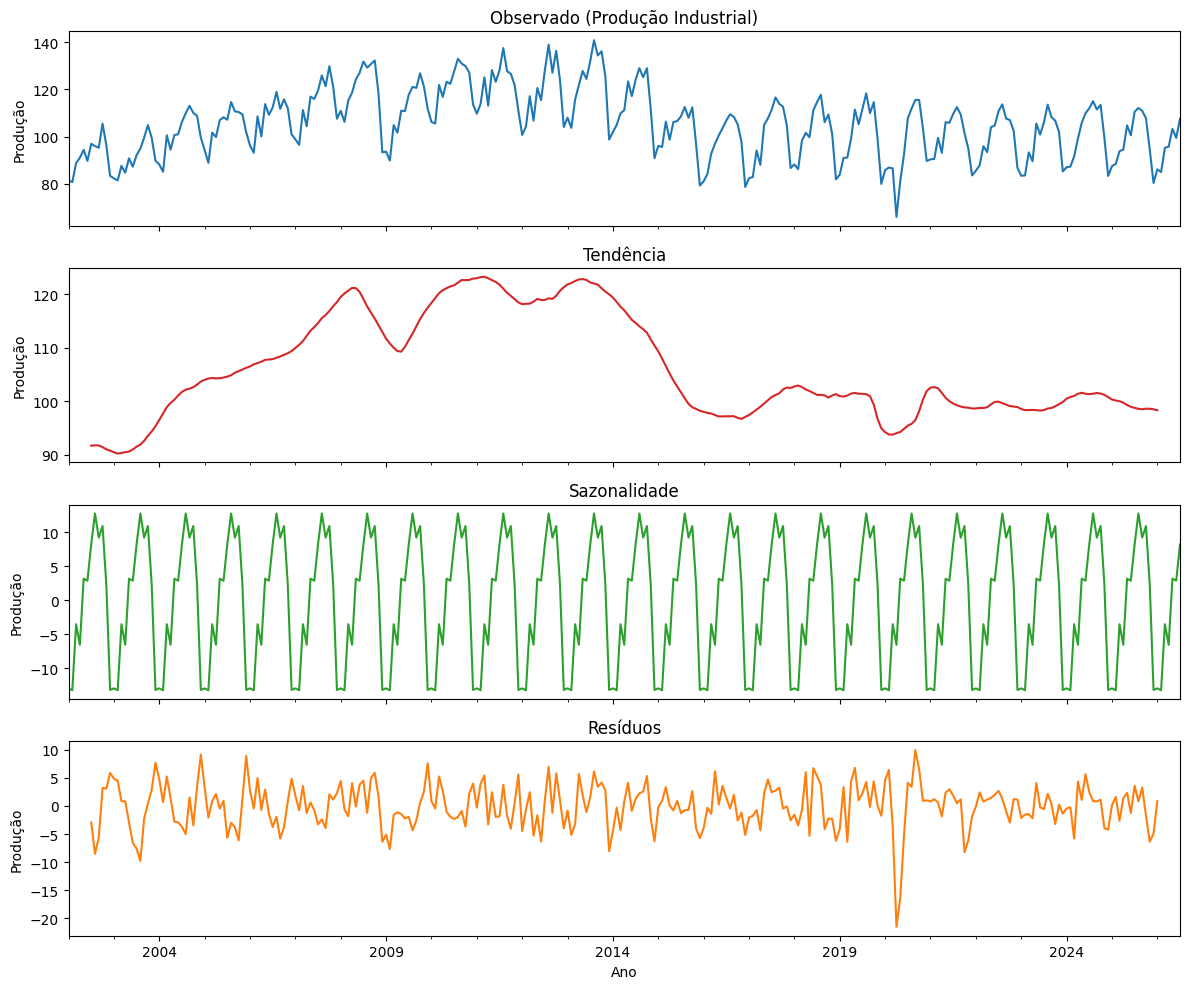

In [17]:
# ANALISE DE TENDENCIAS, SAZONALIDADE E RESIDUO

producaoexplorado = seasonal_decompose(pim['pim_sp'], model='additive', period=12)

# PLOT DOS COMPONENTES
print('Análise de Decomposição da Série Temporal da Produção Industrial no Estado de São Paulo:')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

producaoexplorado.observed.plot(ax=ax1, title='Observado (Produção Industrial)', color='#1f77b4')
ax1.set_ylabel('Produção')

producaoexplorado.trend.plot(ax=ax2, title='Tendência', color='#d62728')
ax2.set_ylabel('Produção')

producaoexplorado.seasonal.plot(ax=ax3, title='Sazonalidade', color='#2ca02c')
ax3.set_ylabel('Produção')

producaoexplorado.resid.plot(ax=ax4, title='Resíduos', color='#ff7f0e')
ax4.set_ylabel('Produção')
ax4.set_xlabel('Ano')

plt.tight_layout()
plt.show()

**FONTE 3 - TEMPERATURA MÉDIA MENSAL - SÃO PAULO**

*NASA POWER*

In [18]:
### Fonte 3: Temperatura média mensal — São Paulo — NASA POWER (T2M) ──
t2m = obter_json('https://power.larc.nasa.gov/api/temporal/monthly/point'
                 '?parameters=T2M&community=AG&longitude=-46.63&latitude=-23.55'
                 '&start=2002&end=2025&format=JSON')['properties']['parameter']['T2M']

In [19]:
# LISTA IMPRESSA
t2mlista = dict(list(t2m.items())[:30])
print(json.dumps(t2mlista, indent=2))

{
  "200201": 22.0,
  "200202": 20.99,
  "200203": 22.68,
  "200204": 21.17,
  "200205": 18.31,
  "200206": 17.48,
  "200207": 15.78,
  "200208": 19.37,
  "200209": 17.77,
  "200210": 23.23,
  "200211": 21.55,
  "200212": 22.46,
  "200213": 20.23,
  "200301": 22.42,
  "200302": 23.6,
  "200303": 21.41,
  "200304": 19.85,
  "200305": 16.34,
  "200306": 17.68,
  "200307": 16.41,
  "200308": 15.74,
  "200309": 18.58,
  "200310": 20.0,
  "200311": 20.64,
  "200312": 22.11,
  "200313": 19.54,
  "200401": 21.11,
  "200402": 20.79,
  "200403": 19.97,
  "200404": 20.12
}


In [20]:
# DESCARTAR MÉDIAS ANUAIS (mês '13')
t2m = {k: v for k, v in t2m.items() if not k.endswith('13')}

In [21]:
temperatura = pd.DataFrame({'data': pd.to_datetime(list(t2m.keys()), format='%Y%m'),
                            'temp_media_c': list(t2m.values())}).set_index('data').asfreq('MS')
temperatura.head()

,temp_media_c
data,
2002-01-01,22.00
2002-02-01,20.99
2002-03-01,22.68
2002-04-01,21.17
2002-05-01,18.31


In [22]:
print(f'Temperatura SP  : {len(temperatura)} registros | {temperatura.index.min():%m/%Y} a {temperatura.index.max():%m/%Y}')

Temperatura SP  : 288 registros | 01/2002 a 12/2025


Análise de Decomposição da Série Temporal da Temperatura no Estado de São Paulo:


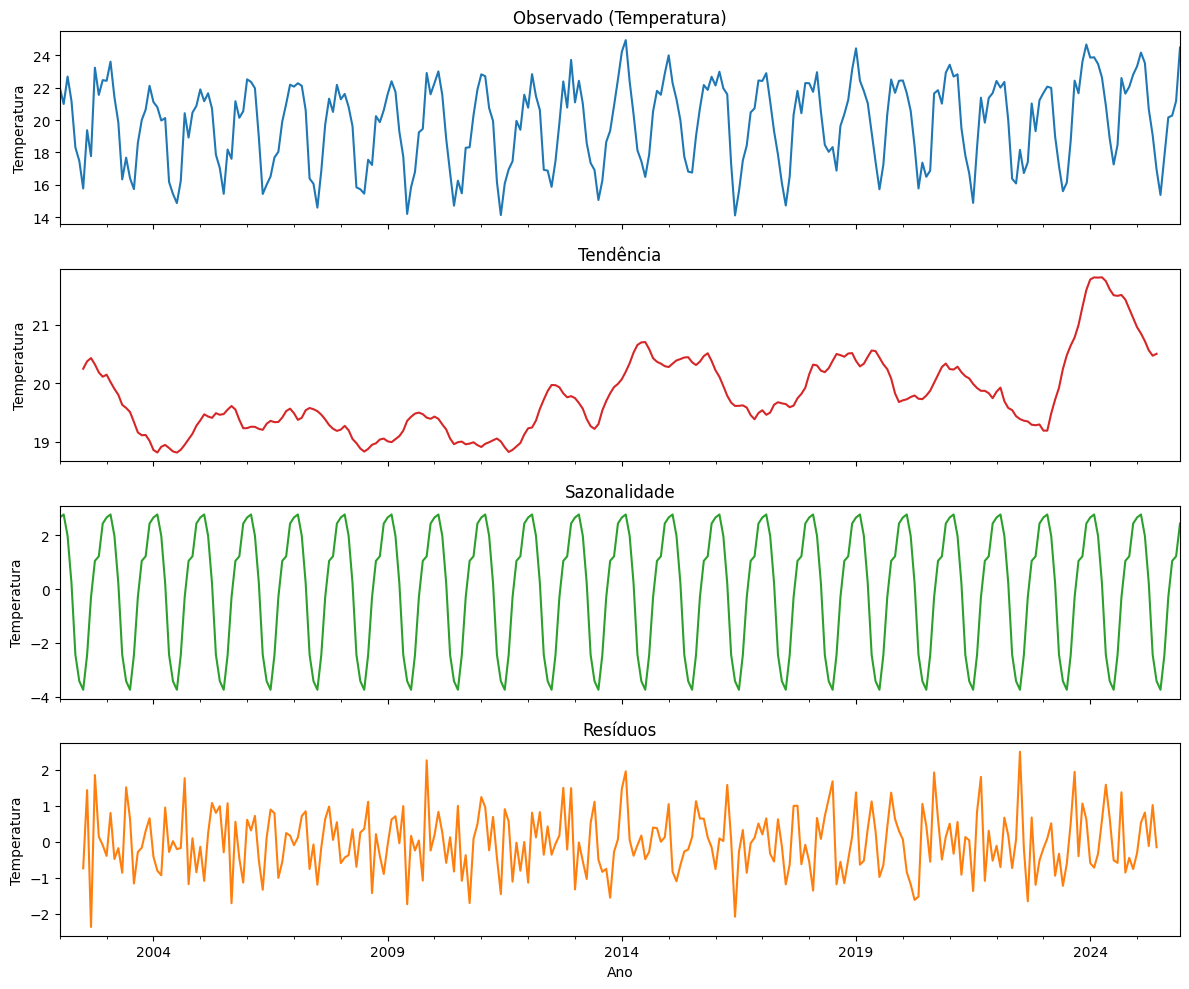

In [23]:
# ANALISE DE TENDENCIAS, SAZONALIDADE E RESIDUO

temperaturaexplorado = seasonal_decompose(temperatura['temp_media_c'], model='additive', period=12)

# PLOT DOS COMPONENTES
print('Análise de Decomposição da Série Temporal da Temperatura no Estado de São Paulo:')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

temperaturaexplorado.observed.plot(ax=ax1, title='Observado (Temperatura)', color='#1f77b4')
ax1.set_ylabel('Temperatura')

temperaturaexplorado.trend.plot(ax=ax2, title='Tendência', color='#d62728')
ax2.set_ylabel('Temperatura')

temperaturaexplorado.seasonal.plot(ax=ax3, title='Sazonalidade', color='#2ca02c')
ax3.set_ylabel('Temperatura')

temperaturaexplorado.resid.plot(ax=ax4, title='Resíduos', color='#ff7f0e')
ax4.set_ylabel('Temperatura')
ax4.set_xlabel('Ano')

plt.tight_layout()
plt.show()

**INTEGRAÇÃO DAS BASES DE DADOS POR MÊS E ANO**

In [24]:
### Integração (join pela chave mês/ano) e verificação de integridade
base = consumo.join([pim, temperatura], how='inner')
base.head()

,consumo_gwh,pim_sp,temp_media_c
data,,,
2002-01-01,12158,81.43223,22.00
2002-02-01,12416,80.73734,20.99
2002-03-01,12803,88.74597,22.68
2002-04-01,13661,91.07592,21.17
2002-05-01,13701,94.41980,18.31


In [25]:
print(f'\nBase integrada  : {base.shape[0]} registros x {base.shape[1]} variáveis '
      f'| {base.index.min():%m/%Y} a {base.index.max():%m/%Y}')
print(f'Valores faltantes: {int(base.isna().sum().sum())}')
base.describe().round(2)


Base integrada  : 288 registros x 3 variáveis | 01/2002 a 12/2025
Valores faltantes: 0


,consumo_gwh,pim_sp,temp_media_c
count,288.00,288.00,288.00
mean,18674.19,105.72,19.80
std,2505.82,14.14,2.58
min,12158.00,65.95,14.12
25%,17013.75,94.80,17.50
50%,19304.50,106.24,20.39
75%,20326.25,114.10,21.91
max,24173.00,140.91,24.93


**VISUALIZAÇÃO DAS TRÊS SÉRIES E EVIDÊNCIA PRELIMINAR DAS RELAÇÕES**

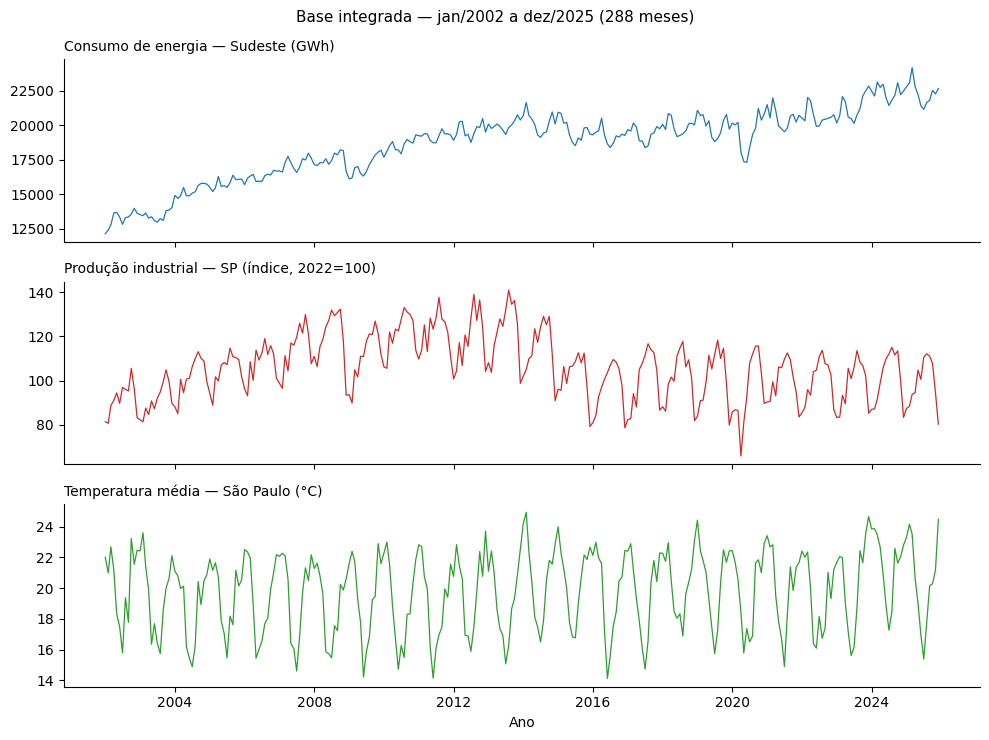

Correlação (variação interanual) consumo x produção industrial: 0.712
Correlação (anomalia sazonal)    consumo x temperatura:         0.543


In [26]:
# VISUALIZAÇÃO DAS TRÊS SÉRIES E EVIDÊNCIA PRELIMINAR DAS RELAÇÕES
fig, eixos = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
series = [('consumo_gwh', 'Consumo de energia — Sudeste (GWh)', '#1f77b4'),
          ('pim_sp', 'Produção industrial — SP (índice, 2022=100)', '#d62728'),
          ('temp_media_c', 'Temperatura média — São Paulo (°C)', '#2ca02c')]
for eixo, (col, titulo, cor) in zip(eixos, series):
    eixo.plot(base.index, base[col], color=cor, linewidth=0.9)
    eixo.set_title(titulo, fontsize=10, loc='left')
    eixo.spines[['top', 'right']].set_visible(False)
eixos[-1].set_xlabel('Ano')
fig.suptitle('Base integrada — jan/2002 a dez/2025 (288 meses)', fontsize=11)
fig.tight_layout()
plt.show()

dif12 = base.diff(12).dropna()          # variação interanual: remove a tendência
anomalia = base - base.groupby(base.index.year).transform('mean')  # anomalia: isola a sazonalidade
print('Correlação (variação interanual) consumo x produção industrial:',
      round(dif12['consumo_gwh'].corr(dif12['pim_sp']), 3))
print('Correlação (anomalia sazonal)    consumo x temperatura:        ',
      round(anomalia['consumo_gwh'].corr(anomalia['temp_media_c']), 3))

# **Modelos**



# **Resultados**


# **Dicussão e Conclusão**

# **Apresentação**

# **Referências**

BANCO CENTRAL DO BRASIL. **Sistema Gerenciador de Séries Temporais (SGS)**: série 1431 — Consumo de energia elétrica — Região Sudeste (GWh), Eletrobras. Brasília, DF, 2026. Disponível em: https://www3.bcb.gov.br/sgspub. Acesso em: 30 ago. 2026.

BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C.; LJUNG, G. M. **Time series analysis**: forecasting and control. 5. ed. Hoboken: John Wiley & Sons, 2015.

ELAMIN, N.; FUKUSHIGE, M. Modeling and forecasting hourly electricity demand by SARIMAX with interactions. **Energy**, v. 165, p. 257-268, 2018. DOI: 10.1016/j.energy.2018.09.157.

EMPRESA DE PESQUISA ENERGÉTICA. **Resenha mensal do mercado de energia elétrica**. Rio de Janeiro: EPE, 2026. Disponível em: https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/consumo-de-energia-eletrica. Acesso em: 30 ago. 2026.

GONÇALVES, I. G. Previsão do consumo de energia elétrica na região Sudeste: aplicação de modelos ARIMA e LSTM. **Revista Brasileira de Estudos Regionais e Urbanos**, v. 19, n. 3, p. 310-340, 2025. DOI: 10.54766/rberu.v19i3.1158.

HOCHREITER, S.; SCHMIDHUBER, J. Long short-term memory. **Neural Computation**, v. 9, n. 8, p. 1735-1780, 1997.

HONG, T.; FAN, S. Probabilistic electric load forecasting: a tutorial review. **International Journal of Forecasting**, v. 32, n. 3, p. 914-938, 2016.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting**: principles and practice. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 30 ago. 2026.

INSTITUTO BRASILEIRO DE GEOGRAFIA E ESTATÍSTICA (IBGE). **Pesquisa Industrial Mensal — Produção Física (PIM-PF)**: tabela 8888 — Produção física industrial, por seções e atividades industriais. Rio de Janeiro, 2026. Disponível em: https://sidra.ibge.gov.br/tabela/8888. Acesso em: 30 ago. 2026.

NASA. **POWER — Prediction Of Worldwide Energy Resources**: monthly temperature at 2 meters (T2M). Hampton: NASA Langley Research Center, 2026. Disponível em: https://power.larc.nasa.gov. Acesso em: 30 ago. 2026.

OPERADOR NACIONAL DO SISTEMA ELÉTRICO (ONS). **Portal de dados abertos**: carga verificada. Rio de Janeiro, 2026. Disponível em: https://dados.ons.org.br. Acesso em: 30 ago. 2026.

ORGANIZAÇÃO DAS NAÇÕES UNIDAS (ONU). **Transformando nosso mundo**: a Agenda 2030 para o Desenvolvimento Sustentável. Nova York: ONU, 2015. Disponível em: https://brasil.un.org/pt-br/91863. Acesso em: 30 ago. 2026.

SANTOS, J. A. A.; CHAUCOSKI, Y. Previsão do consumo de energia elétrica na Região Sudeste: um estudo de caso usando SARIMA e LSTM. **Revista Cereus**, v. 12, n. 4, p. 93-104, 2020.

TAYLOR, S. J.; LETHAM, B. Forecasting at scale. **The American Statistician**, v. 72, n. 1, p. 37-45, 2018.